# Imports

In [8]:
import os
import sys

In [9]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [10]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [7]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [12]:

dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j*Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [13]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [14]:
frank2d = Frank2D(N, rout)

In [15]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


### Previous info
* [50, 60, 70, 80]
* Times taken:  [18.766653370857238, 113.14752146005631, 276.0754511713982, 615.5966497182847]
* MAPs:  [{'m': -1.117858761366558, 'c': 2113.9143893468367, 'l': 56439.90858424367}, {'m': -1.1469933566772985, 'c': 3176.8655479515364, 'l': 57008.99824822997}, {'m': -1.6041499492527893, 'c': 1239869.7155242646, 'l': 52261.44921601237}, {'m': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792}]
* Qmax:  8828201.715647701

In [16]:
#upload the .pkl frank objects and inyect them in the array

#import pickle

#dir = "../../data/exp/N_opt/"

#for i in N_opt:
#    path = dir + 'simulated_opt_Nopt_' + str(i) + '_without_logdetD.pkl'
#    with open(path , 'rb') as f:   # 'rb' = read binary
#        f2d = pickle.load(f)
#        frank2d_objects.append(f2d)

### frank2d

In [17]:
geom = Geometry(0, 0, 0, 0)

In [20]:
N_opt = [50, 60, 70, 80, 100]

In [21]:
maps = [{'m': -1.117858761366558, 'c': 2113.9143893468367, 'l': 56439.90858424367}, {'m': -1.1469933566772985, 'c': 3176.8655479515364, 'l': 57008.99824822997}, {'m': -1.6041499492527893, 'c': 1239869.7155242646, 'l': 52261.44921601237}, {'m': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792}, {'m': -2.935871997869595, 'c': 79462641420506.69, 'l': 45256.85503754103}]

In [22]:
times_opt =  [18.766653370857238, 113.14752146005631, 276.0754511713982, 615.5966497182847,  286.8239773551623]

In [23]:
frank2d_objects = []
times_best = [] # seg


In [24]:
for i in range(len(N_opt)):
    start_time = time.time()

    frank2d = Frank2D(N, Rmax)
    frank2d.process_vis(uvtable)
    #initial_guess = {'m': -2, 'logl': 4}
    #frank2d.search_MAP(initial_guess= initial_guess, N = N_opt[i]) #31m5.5s
    frank2d.fit(uvtable, kernel_params=maps[i], rtol = 1e-10)

    end_time = time.time()
    total_time = end_time - start_time
    print("xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt={} : {:.2f} seconds".format(N_opt[i], total_time))

    times_best.append(total_time)
    frank2d_objects.append(frank2d)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117858761366558, 'c': 2113.9143893468367, 'l': 56439.90858424367}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.03 seconds
        +  Building system = 0.03  min |  2.10 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 249/50000 [00:19<1:05:30, 12.66 iterations/s]


            +  BiCGStab = 0.33  min |  19.70 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.07435963551417657,
 'iterations': 249,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  6.99 seconds
--> times building full visibility model = 0.12  min |  7.02 seconds
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=50 : 31.99 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.1469933566772985, 'c': 3176.8655479515364, 'l': 57008.99824822997}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.03 seconds
        +  Building system = 0.03  min |  2.09 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 298/50000 [00:26<1:13:35, 11.26 iterations/s]


            +  BiCGStab = 0.44  min |  26.48 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 298,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  7.04 seconds
--> times building full visibility model = 0.12  min |  7.07 seconds
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=60 : 38.94 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.6041499492527893, 'c': 1239869.7155242646, 'l': 52261.44921601237}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.92 seconds
        +  Building system = 0.03  min |  1.97 seconds
===>  Solving linear system...


...

            +  BiCGStab = 0.30  min |  18.09 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 243,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.82 seconds
--> times building full visibility model = 0.11  min |  6.85 seconds
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=70 : 29.90 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.61 seconds
        +  Building system = 0.03  min |  1.65 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 175/50000 [00:12<58:00, 14.32 iterations/s]


            +  BiCGStab = 0.20  min |  12.23 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 175,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.67 seconds
--> times building full visibility model = 0.11  min |  6.69 seconds
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=80 : 23.33 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.935871997869595, 'c': 79462641420506.69, 'l': 45256.85503754103}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.50 seconds
        +  Building system = 0.03  min |  1.54 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 380/50000 [00:26<58:08, 14.22 iterations/s]  


            +  BiCGStab = 0.45  min |  26.72 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 380,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.60 seconds
--> times building full visibility model = 0.11  min |  6.63 seconds
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=100 : 37.57 seconds


### frank2d with best values

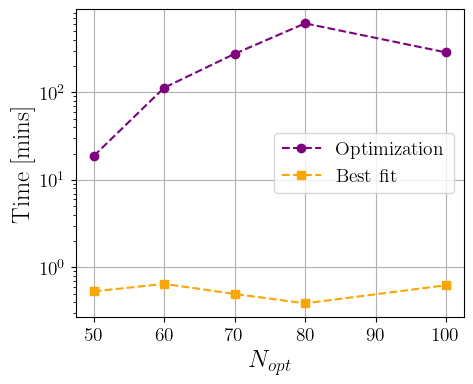

In [25]:
plt.figure(figsize=(5, 4))
plt.plot(N_opt, np.array(times_opt), 'o--', color='purple', label='Optimization')
plt.plot(N_opt, np.array(times_best)/60, 's--', color='orange', label='Best fit')
plt.xlabel(r'$N_{opt}$', fontsize=18)
plt.ylabel("Time [mins]", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.yscale('log')
plt.legend(fontsize=14)
plt.grid()
plt.show()

In [26]:
maps

[{'m': -1.117858761366558, 'c': 2113.9143893468367, 'l': 56439.90858424367},
 {'m': -1.1469933566772985, 'c': 3176.8655479515364, 'l': 57008.99824822997},
 {'m': -1.6041499492527893, 'c': 1239869.7155242646, 'l': 52261.44921601237},
 {'m': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792},
 {'m': -2.935871997869595, 'c': 79462641420506.69, 'l': 45256.85503754103}]

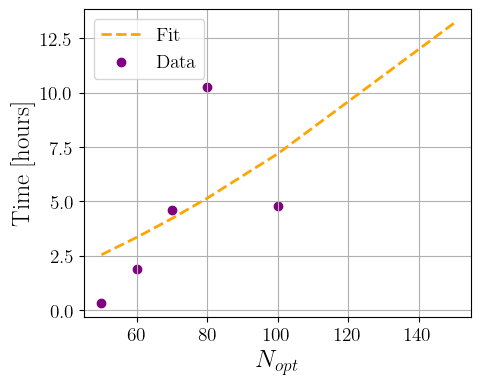

In [28]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x , y = np.array([50, 60, 70, 80, 100]), np.array(times_opt)
x2 = np.array([50, 60, 70, 80, 100, 150])

# Modelo
def modelo(x, a, b):
    return b*x**a

# Ajuste
params, covariance = curve_fit(modelo, x, y)

a, b = params

# Graficar
plt.figure(figsize=(5, 4))
plt.plot(x2, modelo(x2, a, b)/60, label="Fit", linewidth=2, ls='--', c='orange')
plt.scatter(x, y/60, label="Data", c='purple')
plt.xlabel(r'$N_{opt}$', fontsize=18)
plt.ylabel("Time [hours]", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
#plt.yscale('log')
plt.grid()
plt.legend(fontsize=14)
plt.show()

### Plot the stats for posterior

#### function to plot

In [29]:
def plot_MAP_estimation_results(results, results_best, N_opt, normalize = False):
    ms = results['ms']
    cs = results['cs']
    ls = results['ls']
    jDjs = results['jDjs']
    logdetDs = results['logdetDs']
    logdetSs = results['logdetSs']
    minus_log_posteriors = results['minus_log_posteriors']

    m_best = results_best['m']
    c_best = 10**results_best['logc']
    l_best = 10**results_best['logl']
    jDj_best = results_best['jDj']
    logdetD_best = results_best['logdetD']
    logdetS_best = results_best['logdetS']
    minus_log_posterior_best = results_best['minus_log_posterior']

    fig, axs = plt.subplots(3, 3, figsize=(10, 7))
    axs = axs.ravel()

    iterations = np.arange(1, len(ms) + 1)

    axs[0].plot(iterations, ms, '-', c='purple')
    axs[0].set_xlabel('Iteration')
    axs[0].axhline(  m_best, color='gray', linestyle='--',
                        label=r'$m_{best}$ =' + f'{m_best:.2e}')
    axs[0].set_ylabel('m')
    axs[0].legend(fontsize=7, loc='best')

    axs[1].plot(iterations, cs, '-', c='purple')
    axs[1].set_xlabel('Iteration')
    axs[1].axhline( c_best, color='gray', linestyle='--',
                       label=r'$c_{best}$ =' + f'{c_best:.2e}')
    axs[1].set_yscale('log')
    axs[1].set_ylabel('logc')
    axs[1].legend(fontsize=7, loc='best')

    axs[2].plot(iterations, ls, '-', c='purple')
    axs[2].set_xlabel('Iteration')
    axs[2].axhline(  l_best, color='gray', linestyle='--',
                         label=r'$l_{best}$ =' + f'{l_best:.2e}')
    axs[2].set_yscale('log')
    axs[2].set_ylabel('logl')
    axs[2].legend(fontsize=7, loc='best')

    if normalize:
        jDjs = np.abs(jDjs - jDj_best)
        axs[3].set_ylabel(r'$\|jDj- jDj_{best}\|$')
    else:
        axs[3].axhline( jDj_best, color='gray', linestyle='--',
                         label=r'$jDj_{best}$ =' + f'{jDj_best:.2e}')
        axs[3].set_ylabel('jDj')
        axs[3].legend(fontsize=7, loc='best')
    axs[3].set_xlabel('Iteration')
    axs[3].plot(iterations, jDjs, '-', c='red')

    if normalize:
        logdetDs = np.abs(logdetDs - logdetD_best)
        axs[4].set_ylabel(r'$\|log|D| - log|D|_{best}\|$')
    else:
        axs[4].axhline(
            logdetD_best, color='gray', linestyle='--',
            label=r'$log|D|_{best}$ =' + f'{logdetD_best:.2e}')
        axs[4].legend(fontsize=7, loc='best')
        axs[4].set_ylabel('log|D|')
    axs[4].plot(iterations, logdetDs, '-', c='blue')
    axs[4].set_xlabel('Iteration')

    if normalize:
        logdetSs = np.abs(logdetSs-logdetS_best)
        axs[5].set_ylabel(r'$\| log|S| - log|S|_{best}\|$')
    else:
        axs[5].axhline(  logdetS_best, color='gray', linestyle='--',
                         label=r'$log|S|_{best}$ =' + f'{logdetS_best:.2e}')
        axs[5].set_ylabel('log|S|')
        axs[5].legend(fontsize=7, loc='best')
    axs[5].plot(iterations, logdetSs, '-', c='green')
    axs[5].set_xlabel('Iteration')

    if normalize:
        minus_log_posteriors = np.abs(minus_log_posteriors - minus_log_posterior_best)
        axs[7].set_ylabel(r'$\|logP -logP_{best}\|$')
    else:
        axs[7].axhline(  minus_log_posterior_best, color='gray', linestyle='--',
                         label= r'$-logP_{best}$ =' + f'{minus_log_posterior_best:.2e}')
        axs[7].set_ylabel('-logP')
        axs[7].legend(fontsize=7, loc='best')
    axs[7].plot(iterations, minus_log_posteriors, '-', c='black')
    axs[7].set_xlabel('Iteration')

    for ax in [axs[6], axs[8]]:
        fig.delaxes(ax)
    
    #for ax in [axs[3], axs[4], axs[5], axs[7]]:
    #    ax.set_yscale('log')

    for ax in [axs[3], axs[4], axs[5], axs[7]]:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))

    plt.suptitle(r'MAP Estimation $N_{opt}$ = '+ str(N_opt))
    plt.tight_layout()
    plt.show()

#### example with N50

In [ ]:
import pickle
#load object
dir = "../../data/exp/N_opt/"

In [66]:
frank2d_N50 = frank2d_objects[0]

In [69]:
MAPEs_N50 = frank2d_N50.MAPEstimator

In [97]:
best_N50 = {
    'm': frank2d_N50.MAP['m'], 
    'logc': np.log10(frank2d_N50.MAP['c']),
    'logl': np.log10(frank2d_N50.MAP['l'])
}


In [74]:
ms_N50 =  MAPEs_N50._ms
cs_N50 = MAPEs_N50._cs
ls_N50 = MAPEs_N50._ls
jDjs_N50 = MAPEs_N50._jDjs
logdetDs_N50 = MAPEs_N50._logdetDs
logdetSs_N50 = MAPEs_N50._logdetSs
minus_log_posteriors_N50 = MAPEs_N50._minus_log_posteriors

In [96]:
GP_N50 =  MAPEs_N50.GaussianModel


In [98]:
best_minus_log_posteriors_N50 = GP_N50.minus_log_posterior(best_N50)

In [99]:
best_jDj_N50, best_logdetD_N50, best_logdetS_N50 = GP_N50.jDj, GP_N50.logdetD, GP_N50.logdetS

In [118]:
results_N50 = {
    'ms': ms_N50,
    'cs': cs_N50,
    'ls': ls_N50,
    'jDjs': jDjs_N50,
    'logdetDs': logdetDs_N50,
    'logdetSs': logdetSs_N50,
    'minus_log_posteriors': minus_log_posteriors_N50
}

In [119]:
results_best_N50 = {
    'm': best_N50['m'],
    'logc': best_N50['logc'],
    'logl': best_N50['logl'],
    'jDj': best_jDj_N50,
    'logdetD': best_logdetD_N50,
    'logdetS': best_logdetS_N50,
    'minus_log_posteriors': best_minus_log_posteriors_N50
}

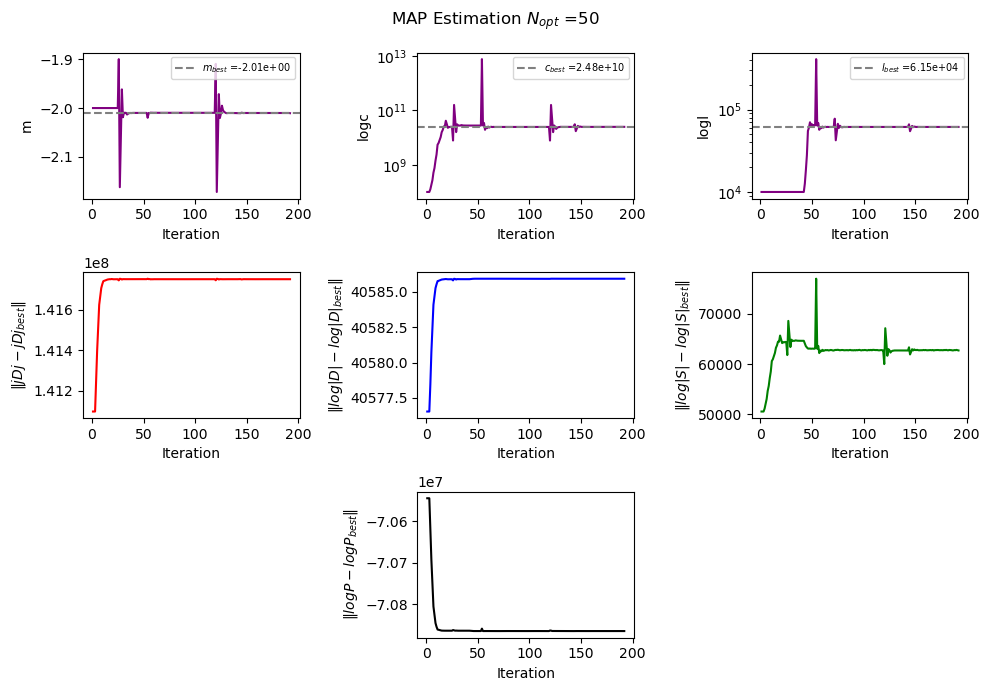

In [209]:
plot_MAP_estimation_results(results_N50, results_best_N50, 50, normalize = True) 

#### run them all

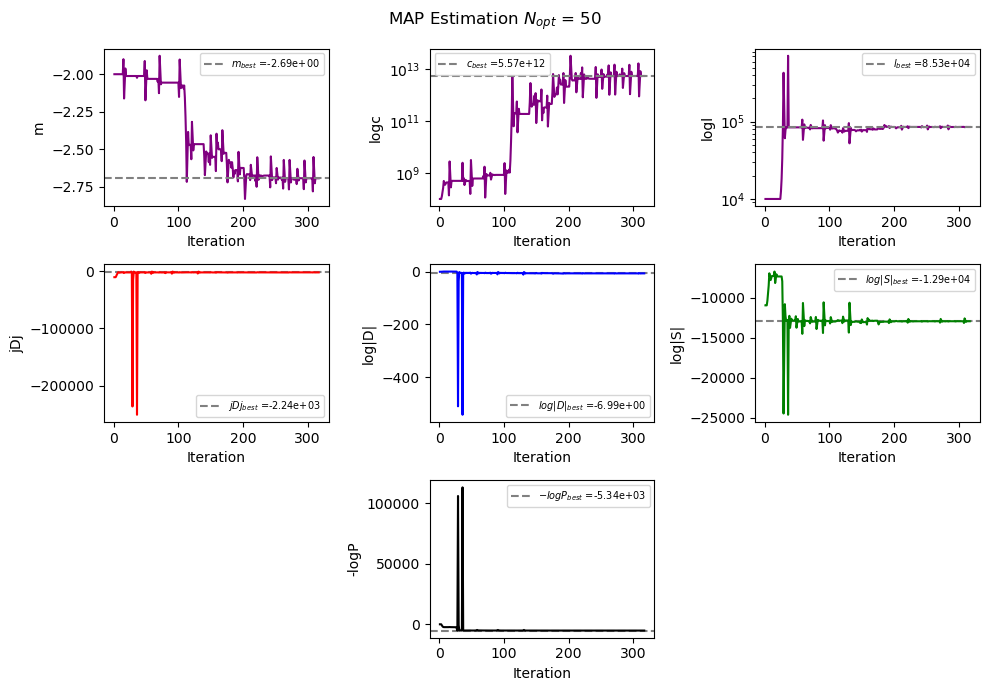

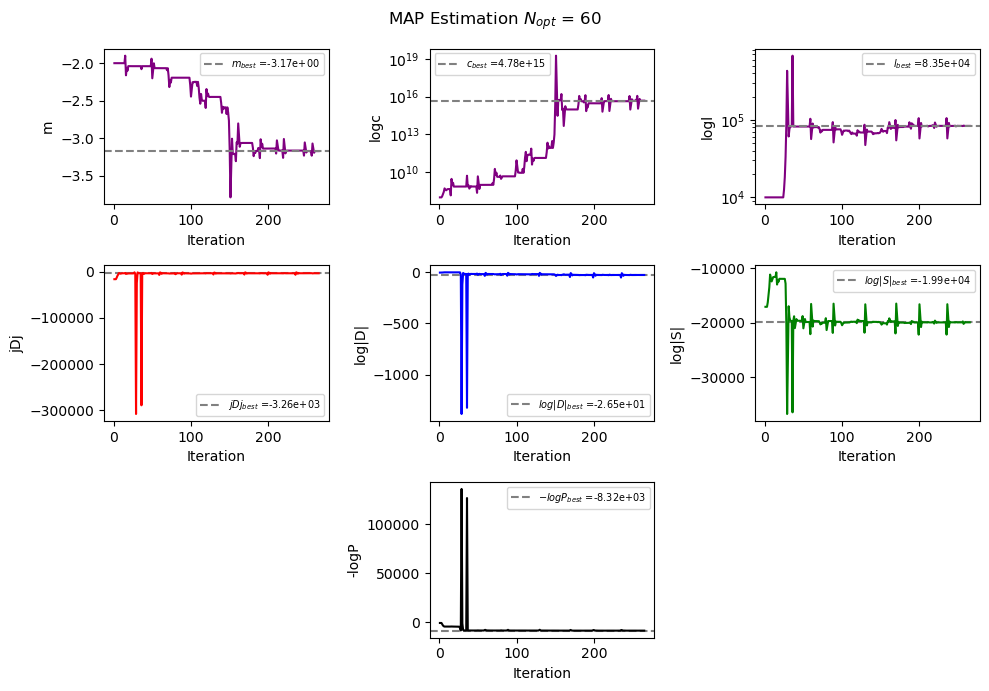

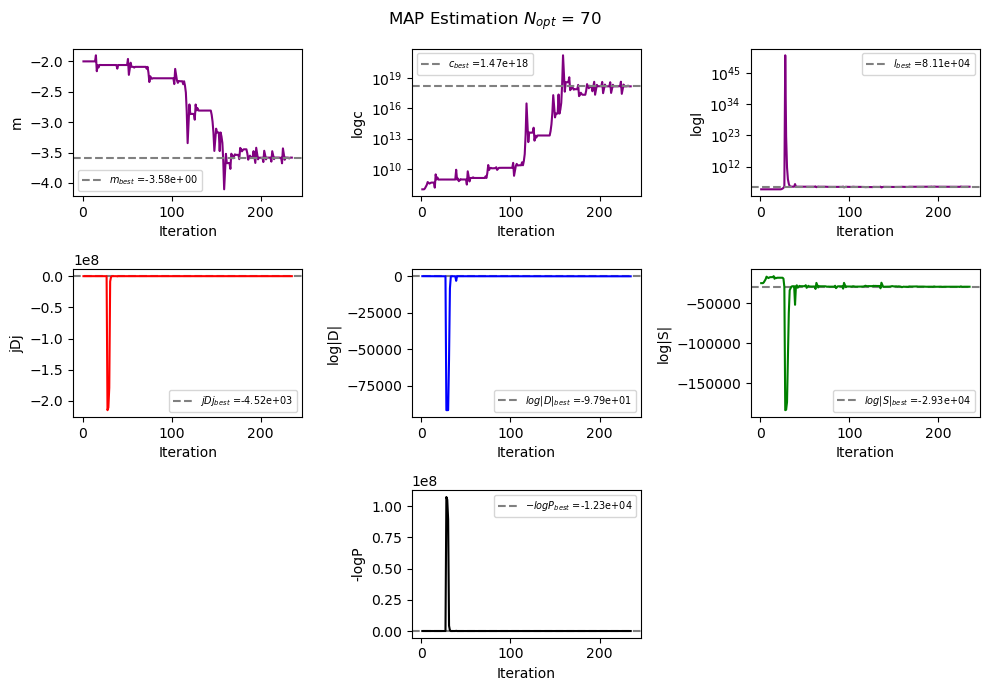

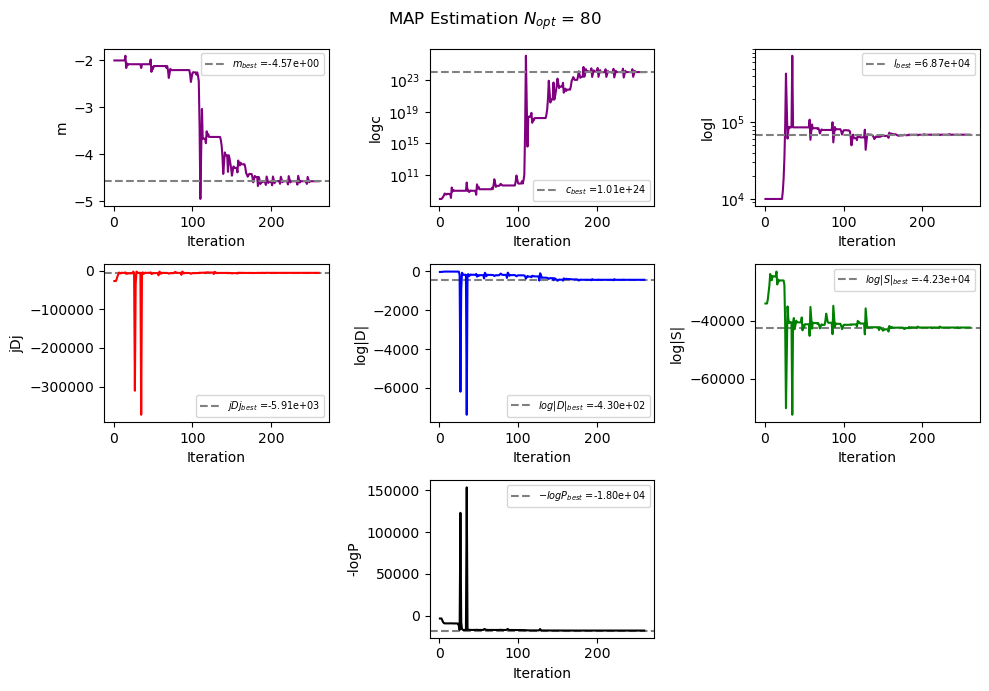

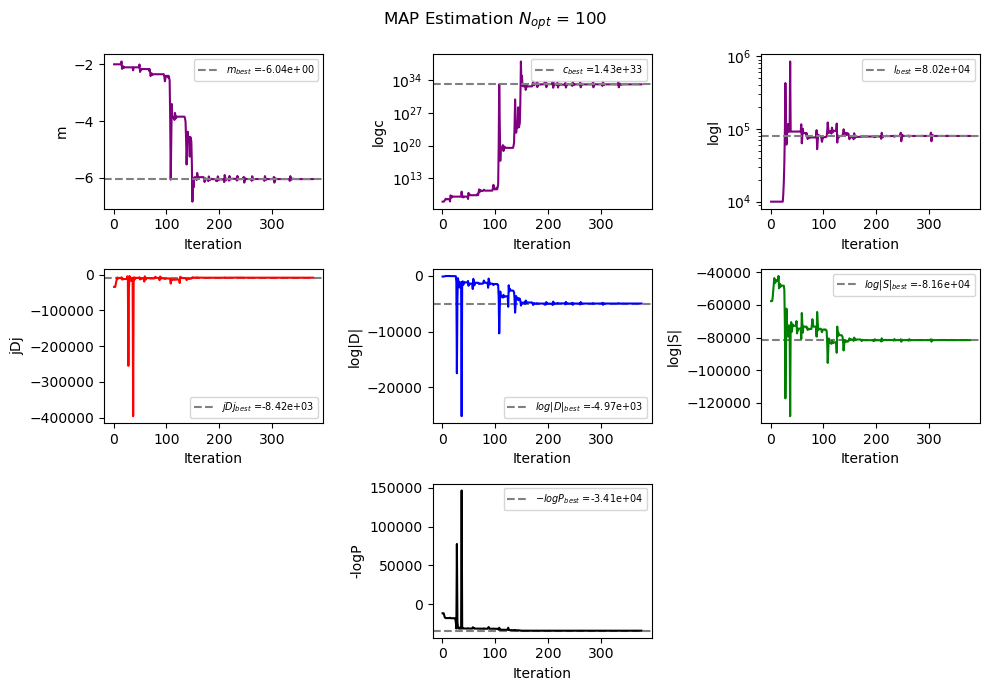

In [53]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator

    MAP_N = frank2d_N.MAP
    m_best_N = MAP_N['m']
    l_best_N = MAP_N['l']
    c_best_N = MAP_N['c']
    logl_best_N = np.log10(l_best_N)
    logc_best_N = np.log10(c_best_N)
    best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N
    }

    ms_N =  MAPEs_N._ms
    cs_N = MAPEs_N._cs
    ls_N = MAPEs_N._ls
    jDjs_N = MAPEs_N._jDjs
    logdetDs_N = MAPEs_N._logdetDs
    logdetSs_N = MAPEs_N._logdetSs
    minus_log_posteriors_N = MAPEs_N._minus_log_posteriors

    results_N = {
        'ms': ms_N,
        'cs': cs_N,
        'ls': ls_N,
        'jDjs': jDjs_N,
        'logdetDs': logdetDs_N,
        'logdetSs': logdetSs_N,
        'minus_log_posteriors': minus_log_posteriors_N,
    }

    GP_N =  MAPEs_N.GaussianModel
    p0, jDj0, logdetS0, logdetD0 = MAPEs_N._p0
    best_minus_log_posteriors_N = GP_N.minus_log_posterior(best_N) -p0
    best_jDj_N, best_logdetD_N, best_logdetS_N = GP_N._jDj - jDj0, GP_N._logdetD-logdetD0, GP_N._logdetS-logdetS0
    
    results_best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N,
        'minus_log_posterior': best_minus_log_posteriors_N,
        'jDj': best_jDj_N,
        'logdetD': best_logdetD_N,
        'logdetS': best_logdetS_N,
    }

    plot_MAP_estimation_results(results_N, results_best_N, N_opt[i], normalize = False) 


### Maximum baseline for each N_opt

In [30]:
Qmaxs = []
for i in range(0, len(N_opt)):
    frank2d = frank2d_objects[i]
    Rmax_radian = frank2d.Rmax/rad_to_arcsec
    print("Rmax_radian =", Rmax_radian)
    MAPEs = MAPEstimator(Rmax_radian, N_opt[i])
    Qmax = MAPEs.Qmax
    print(Qmax)
    Qmaxs.append(Qmax)

Rmax_radian = 1.4544410433286079e-05
1215427.0268120933
Rmax_radian = 1.4544410433286079e-05
1458512.4321745122
Rmax_radian = 1.4544410433286079e-05
1701597.8375369308
Rmax_radian = 1.4544410433286079e-05
1944683.2428993494
Rmax_radian = 1.4544410433286079e-05
2430854.0536241867


In [34]:
Qmaxs

[1215427.0268120933,
 1458512.4321745122,
 1701597.8375369308,
 1944683.2428993494,
 2430854.0536241867]

In [35]:
l_array = []
for i in maps:
    l_array.append(i['l'])

In [38]:
l_array

[56439.90858424367,
 57008.99824822997,
 52261.44921601237,
 45719.70197102792,
 45256.85503754103]

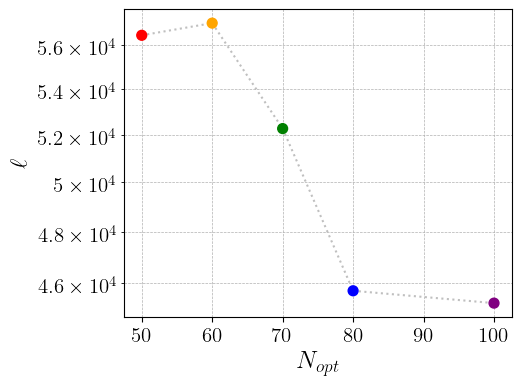

In [52]:
import matplotlib.pyplot as plt

colors = ['r', 'orange', 'g', 'b', 'purple']

plt.figure(figsize=(5,4))

# 1. Dibujamos la línea conectora (solo línea '-')
# Puedes dejarla naranja o ponerla gris para que resalten más los puntos
plt.plot(N_opt, l_array, ':', color='gray', alpha=0.5, zorder=1)

# 2. Dibujamos los puntos encima con 'scatter'
# 'c=colors' aplica tu lista de colores
# 'zorder=2' asegura que los puntos queden encima de la línea
plt.scatter(N_opt, l_array, c=colors, s=50, zorder=2)

plt.yscale('log')
plt.xlabel(r'$N_{opt}$', fontsize=18)
plt.ylabel(r'$\ell$', fontsize=18)
plt.tick_params(axis='both', which='both', labelsize=15)
plt.grid(which='both', linestyle='--', linewidth=0.5)

plt.show()

## Plot the best

In [40]:
times_best2 = []

In [41]:
frank2d_objects_best = []

In [42]:
for i in range(len(frank2d_objects)):
    start = time.time()
    frank2d = Frank2D(N, Rmax)
    maps_i = maps[i]
    frank2d.fit(data = uvtable, kernel_params = maps_i, rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times_best2.append(total_time)
    frank2d_objects_best.append(frank2d)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={maps_i} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117858761366558, 'c': 2113.9143893468367, 'l': 56439.90858424367}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.05 seconds
        +  Building system = 0.04  min |  2.11 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 249/50000 [00:21<1:12:43, 11.40 iterations/s]


            +  BiCGStab = 0.36  min |  21.84 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.07435963551417657,
 'iterations': 249,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  7.09 seconds
--> times building full visibility model = 0.12  min |  7.12 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -1.117858761366558, 'c': 2113.9143893468367, 'l': 56439.90858424367} took 34.29184103012085 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.1469933566772985, 'c': 3176.8655479515364, 'l': 57008.99824822997}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.01 seconds
        +  Building system = 0.03  min |  2.07 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 298/50000 [00:26<1:12:48, 11.38 iterations/s]


            +  BiCGStab = 0.44  min |  26.19 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 298,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  7.09 seconds
--> times building full visibility model = 0.12  min |  7.13 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -1.1469933566772985, 'c': 3176.8655479515364, 'l': 57008.99824822997} took 38.620397090911865 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.6041499492527893, 'c': 1239869.7155242646, 'l': 52261.44921601237}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.83 seconds
        +  Building system = 0.03  min |  1.88 seconds
===>  Solving linear system...


...

            +  BiCGStab = 0.33  min |  19.81 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 243,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.88 seconds
--> times building full visibility model = 0.12  min |  6.91 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -1.6041499492527893, 'c': 1239869.7155242646, 'l': 52261.44921601237} took 31.566970586776733 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.64 seconds
        +  Building system = 0.03  min |  1.68 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 175/50000 [00:13<1:02:00, 13.39 iterations/s]


            +  BiCGStab = 0.22  min |  13.07 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 175,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.78 seconds
--> times building full visibility model = 0.11  min |  6.81 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792} took 24.37430453300476 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.935871997869595, 'c': 79462641420506.69, 'l': 45256.85503754103}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.52 seconds
        +  Building system = 0.03  min |  1.56 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 380/50000 [00:26<56:45, 14.57 iterations/s]  


            +  BiCGStab = 0.43  min |  26.08 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 380,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.66 seconds
--> times building full visibility model = 0.11  min |  6.69 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.935871997869595, 'c': 79462641420506.69, 'l': 45256.85503754103} took 36.97192096710205 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


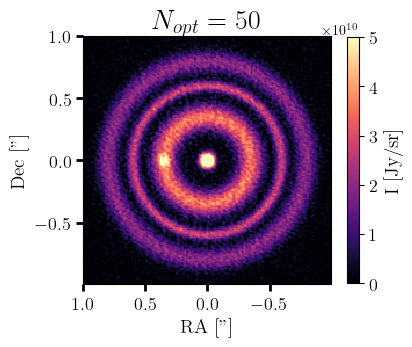

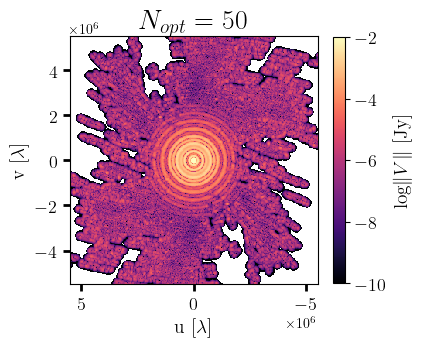

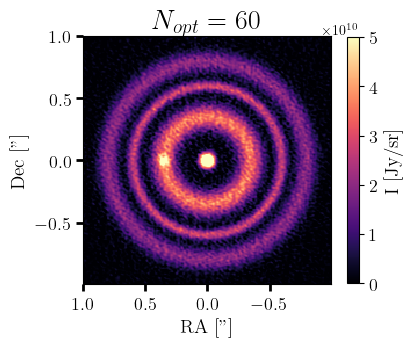

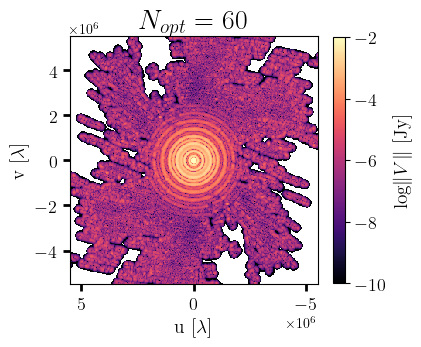

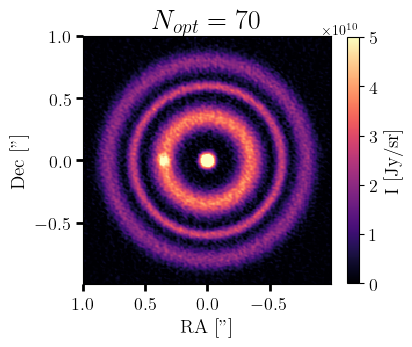

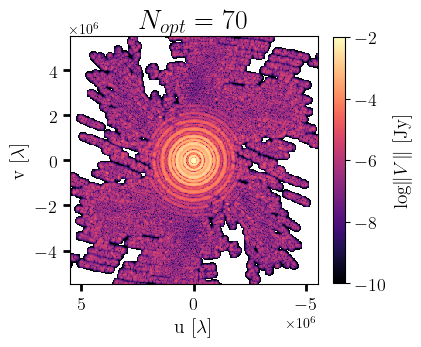

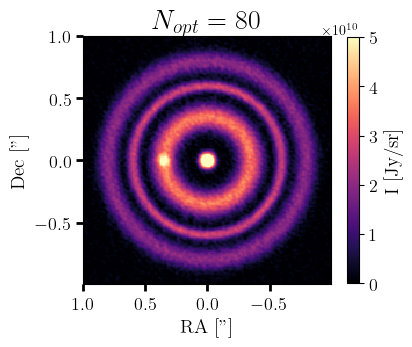

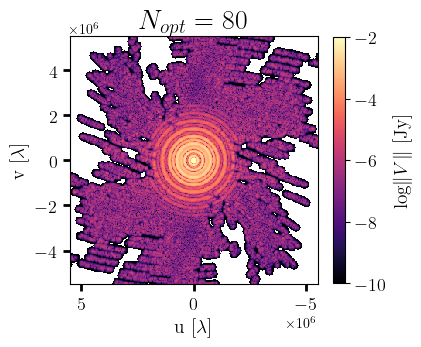

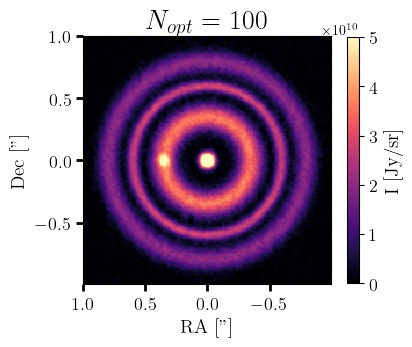

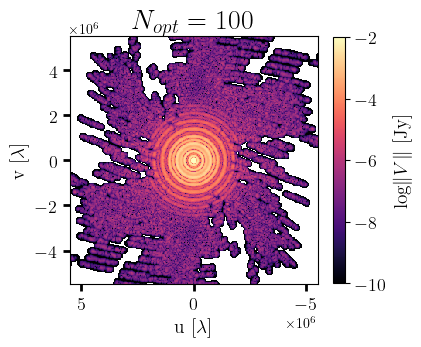

In [43]:
for i in range(len(frank2d_objects_best)):
    Plot_ = Plot(frank2d_objects_best[i], geom)
    Plot_.intensity( vmax=5e10,  gamma = 1, zoom=3, fig_size=4, 
                     title= r'$N_{opt}$ = ' + str(N_opt[i]))
    Plot_.visibility(fig_size = 4, zoom =2,
                     title = r'$N_{opt}$ = ' + str(N_opt[i]))

## Review power spectrum

In [44]:
from frank.utilities import UVDataBinner       

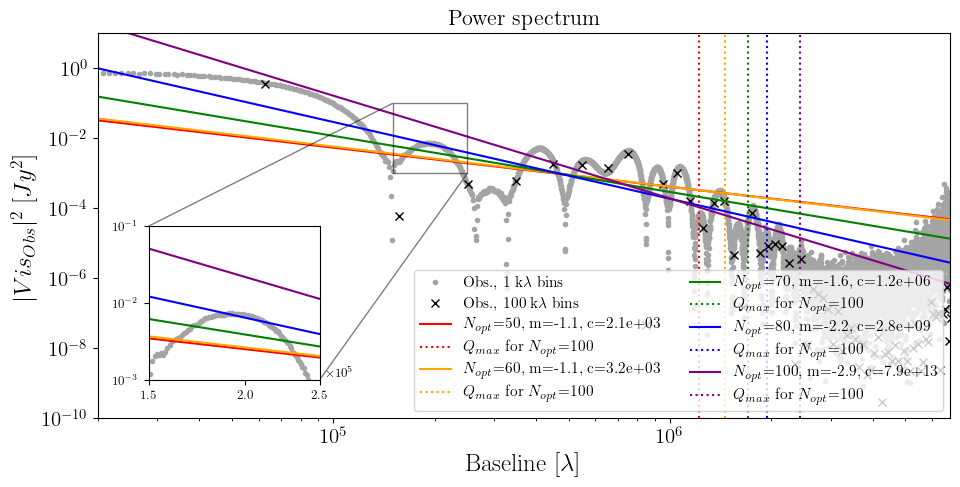

In [48]:
zoom_xlim = [1.5e5, 2.5e5]   # Límites en X (Baseline)
zoom_ylim = [1e-3, 1e-1] # Límites en Y (Visibilidad)

# Define dónde quieres que aparezca el recuadro del zoom dentro del gráfico
# Formato: [x, y, ancho, alto] en coordenadas relativas (0 a 1)
# Ejemplo: [0.05, 0.05, 0.4, 0.4] es abajo a la izquierda
inset_position = [0.06, 0.1, 0.2, 0.4] 

# --- B. CONFIGURACIÓN DE DATOS (Tu código original) ---
N_opts = [50, 60, 70, 80, 100]
colors = ['r', 'orange', 'g', 'b', 'purple']

current_maps = maps[:len(N_opts)] 
current_Qmaxs = Qmaxs[:len(N_opts)]

bin_widths = [1e3, 1e5]
obs_styles = [
    {'color': '#a4a4a4', 'marker': '.', 'label_suffix': ''},
    {'color': 'k',       'marker': 'x', 'label_suffix': ''}
]

def power_spectrum(x, m, c):
    return c * x**(m)

baselines = np.hypot(u, v)
x_model = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)

# --- C. PLOTEO ---
# Creamos figura y ejes principales
fig, ax = plt.subplots(figsize=(11, 5)) # Aumenté un poco el alto para que quepa el zoom

# Creamos el eje del "Zoom" (inset)
axins = ax.inset_axes(inset_position)

# --- BLOQUE 1: Plotear Observaciones ---
for width, style in zip(bin_widths, obs_styles):
    binned = UVDataBinner(baselines, Vis, Weights, width)
    
    # 1. Ploteamos en el eje PRINCIPAL (ax)
    ax.plot(binned.uv, np.abs(binned.V)**2, 
            c=style['color'], marker=style['marker'], ls='None', 
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(width/1e3))
    
    # 2. Ploteamos lo mismo en el eje ZOOM (axins)
    axins.plot(binned.uv, np.abs(binned.V)**2, 
               c=style['color'], marker=style['marker'], ls='None')

# --- BLOQUE 2: Plotear Modelos y Qmax ---
for N, params, Qmax_val, color in zip(N_opts, current_maps, current_Qmaxs, colors):
    if callable(Qmax_val): Qmax = Qmax_val()
    else: Qmax = Qmax_val

    y_model = power_spectrum(x_model, params['m'], params['c'])
    label_text = f"$N_{{opt}}$={N}, m={params['m']:.1f}, c={params['c']:.1e}"
    
    # 1. Eje PRINCIPAL
    ax.plot(x_model, y_model, c=color, label=label_text)
    qmax_label = f"$Q_{{max}}$ for $N_{{opt}}$={N_opts[i]}"
    ax.axvline(Qmax, color=color, ls=':', label=qmax_label)
    
    # 2. Eje ZOOM
    axins.plot(x_model, y_model, c=color)
    axins.axvline(Qmax, color=color, ls=':')

# --- D. CONFIGURACIÓN FINAL ---

# Configuración del Eje Principal
ax.set_xlabel(r'Baseline [$\lambda$]', size=18)
ax.set_ylabel(r'$|Vis_{Obs}|^{2}$ [$Jy^2$]', size=18)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_ylim(1e-10, 10)
ax.set_xlim(2e4, 6.8e6)
ax.set_title("Power spectrum", size=16)
ax.legend(loc='lower right', fontsize=11, ncol=2)

# Configuración del Eje Zoom (axins)
axins.set_xlim(zoom_xlim) # Aquí se aplican tus límites
axins.set_ylim(zoom_ylim) # Aquí se aplican tus límites
axins.set_xscale('log')
axins.set_yscale('log')
# 2. ELIMINAR LA MANCHA NEGRA (Minor Ticks)
# Esto borra las rayitas pequeñas que se amontonan
axins.minorticks_off()

# 3. FORZAR TICKS MANUALES
# Le decimos: "Solo dibuja una línea en estos 3 puntos exactos"
mis_ticks = [1.5e5, 2.0e5, 2.5e5]
axins.set_xticks(mis_ticks)

# 4. FORZAR ETIQUETAS DE TEXTO (Strings)
# Le decimos: "No calcules nada, solo escribe este texto en esos puntos"
# Esto evita que ponga notación científica superpuesta
axins.set_xticklabels(["1.5", "2.0", "2.5"], fontsize=9)

# 5. Agregar manualmente la potencia (x10^5) en la esquina
# coordinates relativas (0 a 1) dentro del axins
axins.text(1.2, 0.01, r'$\times 10^5$', 
           transform=axins.transAxes, ha='right', va='bottom', fontsize=9)

# Configuración del eje Y (lo dejamos automático pero pequeño)
axins.tick_params(axis='y', labelsize=9)

ax.indicate_inset_zoom(axins, edgecolor="black")

plt.show()